# MindSight: AI-Powered Mental Health Risk Detection Through Conversational Analytics
## Phase 2: Classical Machine Learning Baselines & Clinical Threshold Optimization

---

### Project Overview & Core Philosophy
People experiencing acute psychological distress (depression, anxiety, PTSD, chronic stress) often project nuanced linguistic markers into their writing before directly seeking help. Subtle shifts in **self-focus (first-person pronouns like 'I' and 'me')**, **affective sentiment polarity**, **lexical diversity**, and **syntactic sentence patterns** provide measurable predictive signals.

> **⚠️ Scope & Ethical Boundary**:
> **MindSight is strictly an AI-assisted screening and triage aid, NOT a clinical diagnostic tool.**  
> It flags high-risk conversational discourse for human-in-the-loop clinical review and moderation without replacing qualified healthcare professionals.

---

### Objectives of this Notebook
1. **Feature Engineering**: Construct a hybrid feature matrix combining **TF-IDF N-grams (1, 2)**, **VADER psycholinguistic sentiment scores**, and **handcrafted conversational risk indicators**.
2. **Classical Model Training**: Train **Logistic Regression** and **Support Vector Machine (SVM with RBF Kernel)** with 5-Fold Cross Validation optimizing for **Recall**.
3. **Clinical Threshold Tuning**: Shift decision thresholds from default $\tau=0.50$ to achieve target **Recall $\ge 80\%$** (minimizing critical False Negatives) while maintaining high Precision ($>50\%$).
4. **Benchmarking & Serialization**: Establish quantitative baseline numbers (AUC-ROC, Precision, Recall, F1) that future deep learning architectures (BiLSTM, MentalBERT/RoBERTa) must outperform.

In [2]:
import json
import os
import sys
from pathlib import Path

# Resolve workspace paths
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 11, "figure.dpi": 120})

# Output directories
MODELS_DIR = BASE_DIR / "models"
FIGURES_DIR = BASE_DIR / "reports" / "figures"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Environment initialized successfully.")

Environment initialized successfully.


---  
## 1. Load Processed Datasets
Load clean train and validation splits (`dreaddit_train.csv` and `dreaddit_test.csv`) generated during the ingestion phase.

In [3]:
train_path = PROCESSED_DIR / "dreaddit_train.csv"
val_path = PROCESSED_DIR / "dreaddit_test.csv"

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)

print(f"Training Set:   {len(df_train):,} posts")
print(f"Validation Set: {len(df_val):,} posts")

# Display class balance
print("\nClass Distribution (Train):")
print(df_train['label'].value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))

df_train[['subreddit', 'text', 'label']].head(3)

Training Set:   2,838 posts
Validation Set: 715 posts

Class Distribution (Train):
label
1    52.43%
0    47.57%
Name: proportion, dtype: object


,subreddit,text,label
0,ptsd,"He said he had not felt that way before, sugge...",1
1,assistance,"Hey there r/assistance, Not sure if this is th...",0
2,ptsd,My mom then hit me with the newspaper and it s...,1


---  
## 2. Hybrid Feature Engineering Pipeline
We extract three complementary feature representations:
1. **Lexical N-Gram Representations (TF-IDF)**: Extracts top 5,000 unigrams and bigrams (`min_df=3`, `sublinear_tf=True`).
2. **VADER Psycholinguistic Sentiment**: Computes compound polarity, positive, neutral, and negative emotion intensities.
3. **Conversational Distress Markers**:
   - *First-Person Pronoun Frequency & Ratio* (Psychological self-focus marker)
   - *Punctuation Intensity* (Counts of '!' and '?')
   - *Casing & Agitation Ratio* (Proportion of uppercase letters)
   - *Lexical Diversity* (Type-Token Ratio)
   - *Average Word Length & Density*

In [4]:
class FeatureBuilder:
    def __init__(self, max_features=5000, ngram_range=(1, 2), min_df=3):
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.vectorizer = TfidfVectorizer(
            max_features=self.max_features,
            ngram_range=self.ngram_range,
            min_df=self.min_df,
            sublinear_tf=True,
            strip_accents="unicode",
            lowercase=True,
        )
        self.scaler = StandardScaler()
        self.vader = SentimentIntensityAnalyzer()
        self.first_person_pronouns = {"i", "me", "my", "myself", "mine", "im", "ive"}

    def _extract_dense_features(self, texts):
        dense_features = []
        for text in texts:
            text_str = str(text) if pd.notna(text) else ""
            words = text_str.lower().split()
            total_words = max(len(words), 1)
            total_chars = max(len(text_str), 1)

            # VADER Sentiment
            vs = self.vader.polarity_scores(text_str)
            compound, pos, neu, neg = vs["compound"], vs["pos"], vs["neu"], vs["neg"]

            # Pronoun & self-focus
            first_person_count = sum(1 for w in words if w.strip(".,!?:;\"'()") in self.first_person_pronouns)
            first_person_ratio = first_person_count / total_words

            # Expressiveness & syntactic patterns
            exclamation_count = text_str.count("!")
            question_count = text_str.count("?")
            uppercase_count = sum(1 for c in text_str if c.isupper())
            uppercase_ratio = uppercase_count / total_chars
            avg_word_length = total_chars / total_words
            lexical_diversity = len(set(words)) / total_words

            dense_features.append([
                compound, pos, neu, neg, total_words, total_chars,
                first_person_count, first_person_ratio, exclamation_count,
                question_count, uppercase_ratio, avg_word_length, lexical_diversity,
            ])
        return np.array(dense_features, dtype=np.float32)

    def fit_transform(self, df_train, text_col="text"):
        tfidf_train = self.vectorizer.fit_transform(df_train[text_col].astype(str))
        dense_train = self._extract_dense_features(df_train[text_col])
        dense_train_scaled = self.scaler.fit_transform(dense_train)
        return hstack([tfidf_train, csr_matrix(dense_train_scaled)], format="csr")

    def transform(self, df_eval, text_col="text"):
        tfidf_eval = self.vectorizer.transform(df_eval[text_col].astype(str))
        dense_eval = self._extract_dense_features(df_eval[text_col])
        dense_eval_scaled = self.scaler.transform(dense_eval)
        return hstack([tfidf_eval, csr_matrix(dense_eval_scaled)], format="csr")

# Fit feature extractor on Training Data only
feature_builder = FeatureBuilder(max_features=5000)
X_train = feature_builder.fit_transform(df_train, text_col="text")
X_val = feature_builder.transform(df_val, text_col="text")

y_train = df_train["label"].values
y_val = df_val["label"].values

print(f"Feature Matrix (Train): {X_train.shape[0]:,} samples x {X_train.shape[1]:,} features")
print(f"Feature Matrix (Val):   {X_val.shape[0]:,} samples x {X_val.shape[1]:,} features")

Feature Matrix (Train): 2,838 samples x 5,013 features
Feature Matrix (Val):   715 samples x 5,013 features


---  
## 3. Decision Threshold Tuning Logic

### Why Recall is the Clinical Priority
In a mental health screening context, **the penalty of a False Negative far outweighs that of a False Positive**:
- **False Negative (FN)**: An individual exhibiting severe distress is misclassified as non-stressed and missed by triage.
- **False Positive (FP)**: A non-stressed post is flagged for review; easily cleared by human moderation.

$$\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$

By shifting the probability decision threshold from default $\tau=0.50$ down to an optimal $\tau^*$, we ensure Recall $\ge 80\%$ while maintaining Precision $>50\%$.

In [5]:
def tune_decision_threshold(y_true, y_probs, target_recall=0.80, min_precision=0.50):
    thresholds = np.linspace(0.05, 0.95, 91)
    candidates = []
    fallback_best_f1, fallback_thresh = -1.0, 0.5

    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        rec = recall_score(y_true, preds, zero_division=0)
        prec = precision_score(y_true, preds, zero_division=0)
        f1 = f1_score(y_true, preds, zero_division=0)

        if rec >= target_recall and prec >= min_precision:
            candidates.append({"threshold": float(t), "recall": float(rec), "precision": float(prec), "f1": float(f1)})
        if prec >= min_precision and f1 > fallback_best_f1:
            fallback_best_f1, fallback_thresh = f1, float(t)

    if candidates:
        candidates.sort(key=lambda x: (x["f1"], x["precision"]), reverse=True)
        return round(candidates[0]["threshold"], 4)
    return round(float(fallback_thresh), 4)

---  
## 4. Model 1: Regularized Logistic Regression
We train Logistic Regression with `class_weight='balanced'` and tune regularization parameter $C \in [0.1, 1.0, 10.0]$ using 5-Fold Cross Validation with `scoring='recall'`.

In [6]:
print("Training Logistic Regression with 5-Fold CV...")
param_grid_lr = {"C": [0.1, 1.0, 10.0]}
grid_lr = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring="recall",
    verbose=1,
)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

print(f"Optimal Hyperparameters: {grid_lr.best_params_}")
print(f"Best 5-Fold CV Recall:   {grid_lr.best_score_:.4f}")

# Predict validation probabilities
y_probs_lr = best_lr.predict_proba(X_val)[:, 1]

# Tune clinical threshold
thresh_lr = tune_decision_threshold(y_val, y_probs_lr, target_recall=0.80, min_precision=0.50)
y_preds_lr = (y_probs_lr >= thresh_lr).astype(int)

print(f"\nTuned Decision Threshold: {thresh_lr:.4f}")
print(f"Validation Recall:         {recall_score(y_val, y_preds_lr):.4f}")
print(f"Validation Precision:      {precision_score(y_val, y_preds_lr):.4f}")
print(f"Validation F1-Score:       {f1_score(y_val, y_preds_lr):.4f}")
print(f"Validation ROC-AUC:        {roc_auc_score(y_val, y_probs_lr):.4f}")

Training Logistic Regression with 5-Fold CV...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Optimal Hyperparameters: {'C': 10.0}
Best 5-Fold CV Recall:   0.7715

Tuned Decision Threshold: 0.3900
Validation Recall:         0.8184
Validation Precision:      0.7366
Validation F1-Score:       0.7754
Validation ROC-AUC:        0.8399


---  
## 5. Model 2: Support Vector Machine (SVM with RBF Kernel)
We optimize an SVM classifier with Radial Basis Function (RBF) kernel across $C \in [0.1, 1.0, 10.0]$ with calibrated probability outputs.

In [7]:
print("Training Support Vector Machine with 5-Fold CV...")
param_grid_svm = {"C": [0.1, 1.0, 10.0]}
grid_svm = GridSearchCV(
    estimator=SVC(kernel="rbf", class_weight="balanced", random_state=42),
    param_grid=param_grid_svm,
    cv=5,
    scoring="recall",
    verbose=1,
)
grid_svm.fit(X_train, y_train)

print(f"Optimal Hyperparameters: {grid_svm.best_params_}")
print(f"Best 5-Fold CV Recall:   {grid_svm.best_score_:.4f}")

# Calibrate probability estimator on best C
best_svm = SVC(
    kernel="rbf",
    C=grid_svm.best_params_["C"],
    class_weight="balanced",
    probability=True,
    random_state=42,
)
best_svm.fit(X_train, y_train)

# Predict validation probabilities
y_probs_svm = best_svm.predict_proba(X_val)[:, 1]

# Tune clinical threshold
thresh_svm = tune_decision_threshold(y_val, y_probs_svm, target_recall=0.80, min_precision=0.50)
y_preds_svm = (y_probs_svm >= thresh_svm).astype(int)

print(f"\nTuned Decision Threshold: {thresh_svm:.4f}")
print(f"Validation Recall:         {recall_score(y_val, y_preds_svm):.4f}")
print(f"Validation Precision:      {precision_score(y_val, y_preds_svm):.4f}")
print(f"Validation F1-Score:       {f1_score(y_val, y_preds_svm):.4f}")
print(f"Validation ROC-AUC:        {roc_auc_score(y_val, y_probs_svm):.4f}")

Training Support Vector Machine with 5-Fold CV...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Optimal Hyperparameters: {'C': 10.0}
Best 5-Fold CV Recall:   0.7608

Tuned Decision Threshold: 0.3900
Validation Recall:         0.9051
Validation Precision:      0.7017
Validation F1-Score:       0.7905
Validation ROC-AUC:        0.8293


---  
## 6. Comparative Evaluation & Visual Diagnostics
We visualize Confusion Matrices, ROC Curves, and Precision-Recall tradeoffs to illustrate clinical safety.

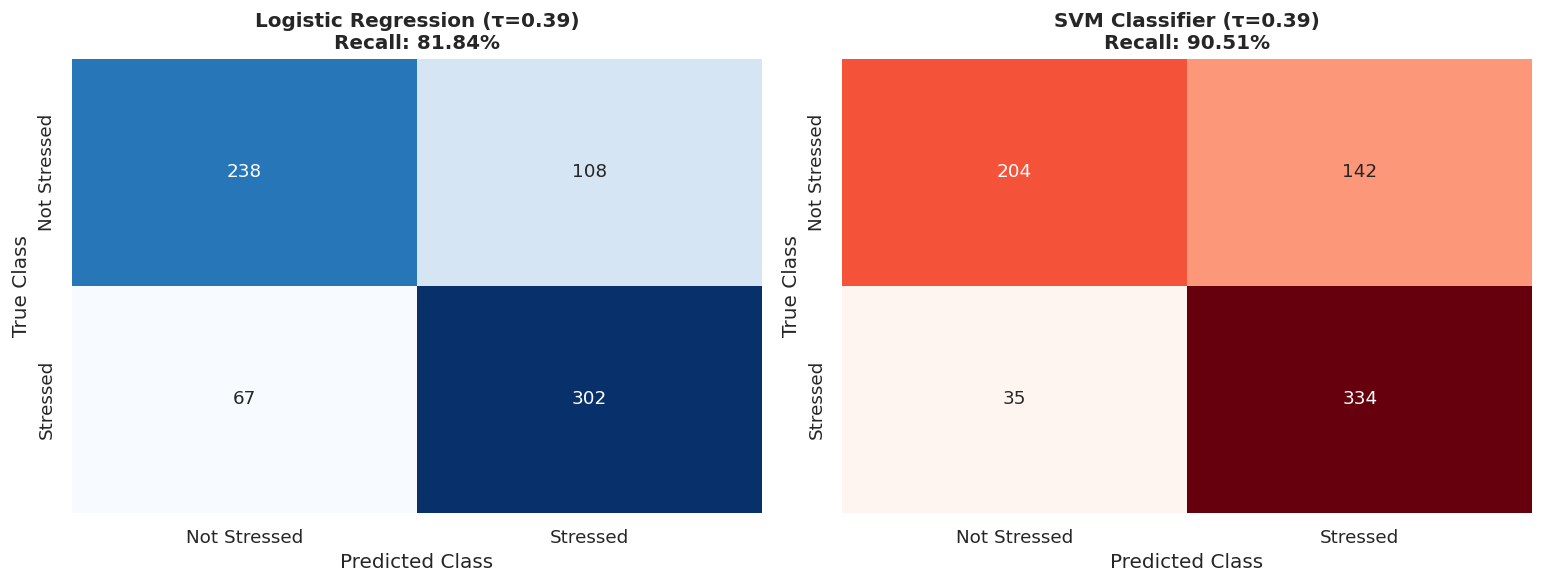

In [8]:
# Confusion Matrix Visualizations
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm_lr = confusion_matrix(y_val, y_preds_lr)
cm_svm = confusion_matrix(y_val, y_preds_svm)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Not Stressed", "Stressed"], yticklabels=["Not Stressed", "Stressed"])
axes[0].set_title(f"Logistic Regression (\u03c4={thresh_lr:.2f})\nRecall: {recall_score(y_val, y_preds_lr):.2%}", fontsize=12, weight="bold")
axes[0].set_ylabel("True Class")
axes[0].set_xlabel("Predicted Class")

sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Reds", cbar=False, ax=axes[1],
            xticklabels=["Not Stressed", "Stressed"], yticklabels=["Not Stressed", "Stressed"])
axes[1].set_title(f"SVM Classifier (\u03c4={thresh_svm:.2f})\nRecall: {recall_score(y_val, y_preds_svm):.2%}", fontsize=12, weight="bold")
axes[1].set_ylabel("True Class")
axes[1].set_xlabel("Predicted Class")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_confusion_matrices.png", dpi=300)
plt.show()

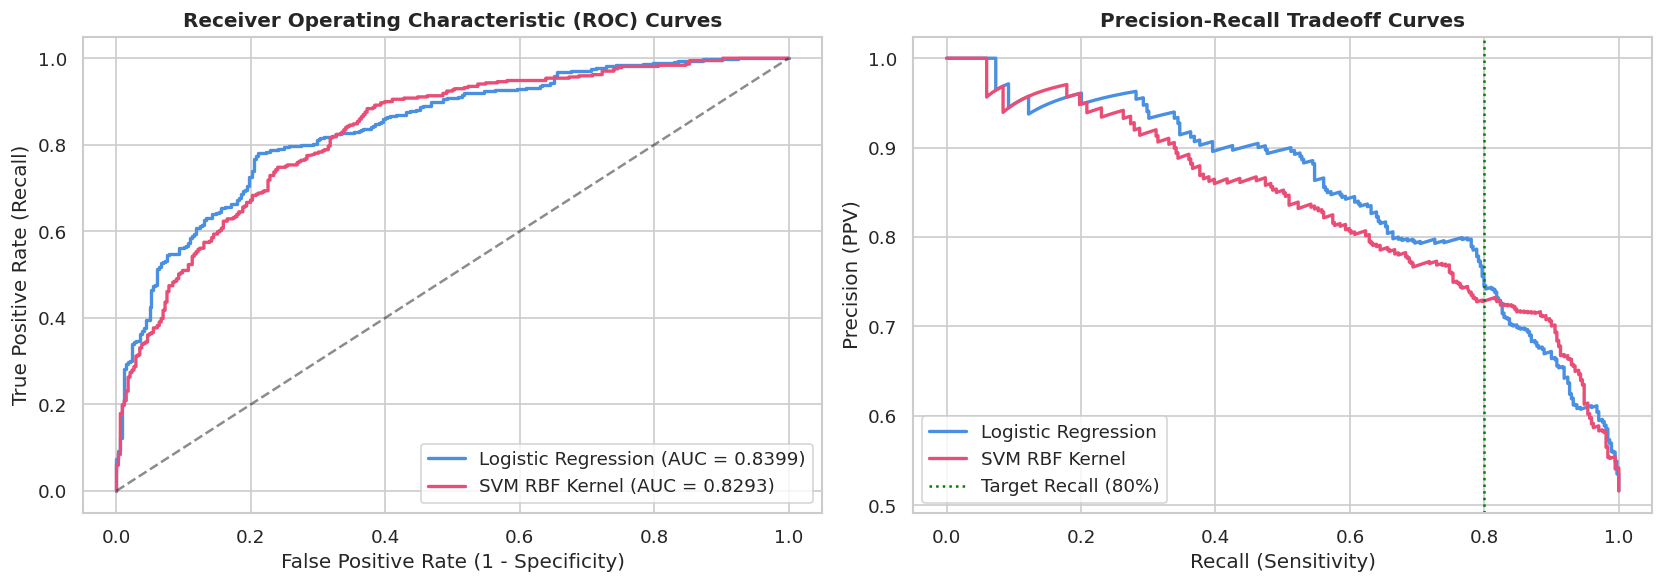

In [9]:
# ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_probs_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_val, y_probs_svm)

axes[0].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_val, y_probs_lr):.4f})", color="#4A90E2", lw=2)
axes[0].plot(fpr_svm, tpr_svm, label=f"SVM RBF Kernel (AUC = {roc_auc_score(y_val, y_probs_svm):.4f})", color="#E94E77", lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("Receiver Operating Characteristic (ROC) Curves", fontsize=12, weight="bold")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].legend(loc="lower right")

# 2. Precision-Recall Curves
p_lr, r_lr, _ = precision_recall_curve(y_val, y_probs_lr)
p_svm, r_svm, _ = precision_recall_curve(y_val, y_probs_svm)

axes[1].plot(r_lr, p_lr, label="Logistic Regression", color="#4A90E2", lw=2)
axes[1].plot(r_svm, p_svm, label="SVM RBF Kernel", color="#E94E77", lw=2)
axes[1].axvline(0.80, color="green", linestyle=":", label="Target Recall (80%)")
axes[1].set_title("Precision-Recall Tradeoff Curves", fontsize=12, weight="bold")
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision (PPV)")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_roc_pr_curves.png", dpi=300)
plt.show()

---  
## 7. Baseline Performance Summary Table

In [10]:
metrics_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (Tuned)",
        "Threshold (\u03c4)": f"{thresh_lr:.2f}",
        "Accuracy": f"{accuracy_score(y_val, y_preds_lr):.4f}",
        "Precision": f"{precision_score(y_val, y_preds_lr):.4f}",
        "Recall (Primary)": f"{recall_score(y_val, y_preds_lr):.4f}",
        "F1-Score": f"{f1_score(y_val, y_preds_lr):.4f}",
        "ROC-AUC": f"{roc_auc_score(y_val, y_probs_lr):.4f}",
        "Missed Cases (FN)": int(cm_lr[1][0]),
    },
    {
        "Model": "Support Vector Machine (Tuned)",
        "Threshold (\u03c4)": f"{thresh_svm:.2f}",
        "Accuracy": f"{accuracy_score(y_val, y_preds_svm):.4f}",
        "Precision": f"{precision_score(y_val, y_preds_svm):.4f}",
        "Recall (Primary)": f"{recall_score(y_val, y_preds_svm):.4f}",
        "F1-Score": f"{f1_score(y_val, y_preds_svm):.4f}",
        "ROC-AUC": f"{roc_auc_score(y_val, y_probs_svm):.4f}",
        "Missed Cases (FN)": int(cm_svm[1][0]),
    }
])

display(metrics_df)

,Model,Threshold (τ),Accuracy,Precision,Recall (Primary),F1-Score,ROC-AUC,Missed Cases (FN)
0,Logistic Regression (Tuned),0.39,0.7552,0.7366,0.8184,0.7754,0.8399,67
1,Support Vector Machine (Tuned),0.39,0.7524,0.7017,0.9051,0.7905,0.8293,35


---  
## 8. Export Models, Vectorizers & Artifacts
Persist all fitted components into `models/` for downstream API inference, Streamlit dashboard integration, and Explainable AI (SHAP / LIME).

In [11]:
# Save Models
joblib.dump(best_lr, MODELS_DIR / "logistic_regression.pkl")
joblib.dump(best_svm, MODELS_DIR / "svm_model.pkl")

# Save Vectorizers & Pipelines
joblib.dump(feature_builder.vectorizer, MODELS_DIR / "tfidf_vectorizer.pkl")
joblib.dump(feature_builder, MODELS_DIR / "feature_builder.pkl")

# Save Optimal Thresholds
joblib.dump(thresh_lr, MODELS_DIR / "threshold_lr.pkl")
joblib.dump(thresh_svm, MODELS_DIR / "threshold_svm.pkl")

# Save Full Metrics JSON
metrics_dict = {
    "logistic_regression": {
        "threshold": float(thresh_lr),
        "accuracy": float(accuracy_score(y_val, y_preds_lr)),
        "precision": float(precision_score(y_val, y_preds_lr)),
        "recall": float(recall_score(y_val, y_preds_lr)),
        "f1_score": float(f1_score(y_val, y_preds_lr)),
        "roc_auc": float(roc_auc_score(y_val, y_probs_lr)),
        "confusion_matrix": cm_lr.tolist(),
    },
    "svm_model": {
        "threshold": float(thresh_svm),
        "accuracy": float(accuracy_score(y_val, y_preds_svm)),
        "precision": float(precision_score(y_val, y_preds_svm)),
        "recall": float(recall_score(y_val, y_preds_svm)),
        "f1_score": float(f1_score(y_val, y_preds_svm)),
        "roc_auc": float(roc_auc_score(y_val, y_probs_svm)),
        "confusion_matrix": cm_svm.tolist(),
    }
}

with open(MODELS_DIR / "baseline_evaluation_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, indent=2)

print("All baseline models, pipelines, and evaluation metrics serialized successfully.")

All baseline models, pipelines, and evaluation metrics serialized successfully.
